# Six conditions, one pipeline

Nightingale trains a calibrated risk model for six clinical conditions, pulled directly
from public UCI repositories, through one shared fetch &rarr; clean &rarr; train &rarr;
evaluate pipeline. This notebook walks through that pipeline end to end: the six data
sources, the integrity checks that catch the ways this kind of data quietly lies, the
training protocol (and a calibration bug this project found and fixed in itself), the
published per-condition results, a deep look at the one result that looked too good to
be true, and the honest limitations of what is published here.

Every number below is loaded from a committed artifact (`models/*/metrics.json`,
`models/*/oof_predictions.csv.gz`, or the cleaned data itself) and printed with an
f-string — nothing is hand-typed, so there is no way for a quoted number to drift from
what is actually checked into the repository.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

import json
import numpy as np
import pandas as pd
from IPython.display import Image, display

from nightingale.conditions import CONDITIONS
from nightingale.sentinel import scan_sentinel_zeros
from nightingale.calibrate import ece, fit_calibrator
from nightingale.model import train_condition
from nightingale.conformal import conformal_qhat, prediction_set

MODELS_ROOT = ROOT / "models"
FIGURES_ROOT = ROOT / "reports" / "figures"
RAW_ROOT = ROOT / "data" / "raw"
CLEANED_ROOT = ROOT / "data" / "cleaned"

pd.set_option("display.width", 120)
print("repo root:", ROOT)

repo root: /Users/safdarhussain/Desktop/Projects/GitHub/nightingale


## The six conditions

Each row below comes straight from the condition registry
(`src/nightingale/conditions.py`), the single place every later stage — fetch, clean,
train, export — reads a condition's source, expected row count, and target semantics
from.

In [2]:
sources = pd.DataFrame(
    [
        {
            "slug": c.slug,
            "condition": c.display,
            "source": c.source,
            "fetch_mode": c.fetch_mode,
            "rows": c.n_rows,
            "positive_meaning": c.positive_meaning,
        }
        for c in CONDITIONS.values()
    ]
).set_index("slug")
sources

,condition,source,fetch_mode,rows,positive_meaning
slug,,,,,
breast-cancer,Breast cancer (WDBC),UCI 17,ucimlrepo,569,malignant tumour
cervical-cancer,Cervical cancer (risk factors),UCI 383,zip,858,positive cervical cancer biopsy
heart-disease,Heart disease (four-hospital cohort),UCI 45,zip,920,presence of heart disease (num > 0)
kidney-disease,Chronic kidney disease,UCI 336,ucimlrepo,400,chronic kidney disease diagnosis (ckd)
liver-disease,Liver disease (ILPD),UCI 225,ucimlrepo,583,liver patient (Selector == 1)
diabetes,Diabetes (CDC BRFSS-2015),UCI 891,ucimlrepo,253680,self-reported diabetes or prediabetes


## The data-integrity gauntlet

Public clinical datasets encode missingness, dirty labels, and inverted conventions in
ways that a naive `read_csv` + `fit` pipeline will happily learn as signal. Three real
examples this project's cleaning step exists to catch, shown live against the raw files
(not the already-cleaned CSVs) so the "before" state is genuine.

### 1. Switzerland's cholesterol is not real

`nightingale.sentinel.scan_sentinel_zeros` flags a numeric column when at least 5% of
its non-missing values are exactly `0` *and* `0` sits below the low fence a genuine
reading of that column would plausibly reach — i.e. an implausible spike, not a
column whose real values legitimately touch zero.

In [3]:
_HEART_COLUMNS = (
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", "thalach",
    "exang", "oldpeak", "slope", "ca", "thal", "num",
)

switzerland_raw = pd.read_csv(
    RAW_ROOT / "heart-disease" / "processed.switzerland.data",
    header=None, names=list(_HEART_COLUMNS), na_values="?",
)

flags = scan_sentinel_zeros(switzerland_raw)
print("scan_sentinel_zeros(switzerland raw) ->", flags)
chol_zero_frac = flags.get("chol")
print(f"\n{chol_zero_frac:.1%} of Switzerland's raw, non-missing chol readings are exactly 0.")
print("Serum cholesterol of 0 is not physiologically possible in a living patient — this is a")
print("missing-value sentinel, not a real reading.")

scan_sentinel_zeros(switzerland raw) -> {'chol': 1.0, 'restecg': 0.6967213114754098}

100.0% of Switzerland's raw, non-missing chol readings are exactly 0.
Serum cholesterol of 0 is not physiologically possible in a living patient — this is a
missing-value sentinel, not a real reading.


The cleaner (`nightingale.clean._apply_heart_sentinels`) converts `chol == 0` to `NaN`,
scoped to the Switzerland and VA sites only — Cleveland and Hungary never emit a genuine
`chol == 0`, so applying the rule globally would corrupt any real low reading those two
sites happened to record. Re-running the same scan on the cleaned data proves the fix
actually removes the flag it was built to catch.

In [4]:
switzerland_cleaned = pd.read_csv(CLEANED_ROOT / "heart-disease.csv.gz", compression="gzip")
switzerland_cleaned = switzerland_cleaned[switzerland_cleaned["site"] == "switzerland"]

chol_all_nan = switzerland_cleaned["chol"].isna().all()
flags_cleaned = scan_sentinel_zeros(switzerland_cleaned.drop(columns=["site"]))

print(f"Switzerland chol, cleaned: {switzerland_cleaned['chol'].isna().mean():.1%} NaN "
      f"(all rows: {chol_all_nan})")
print("scan_sentinel_zeros(switzerland cleaned) ->", flags_cleaned)
print("\n'chol' no longer appears in the cleaned-data flags: the cleaner and the detector agree.")

Switzerland chol, cleaned: 100.0% NaN (all rows: True)
scan_sentinel_zeros(switzerland cleaned) -> {'restecg': 0.6967213114754098}

'chol' no longer appears in the cleaned-data flags: the cleaner and the detector agree.


### 2. Kidney disease's whitespace-dirty label

The raw `class` column for chronic kidney disease carries a trailing-tab variant of its
positive label — invisible in a casual `print`, but a silent third class to anything that
matches strings exactly.

In [5]:
kidney_targets_raw = pd.read_csv(RAW_ROOT / "kidney-disease" / "targets.csv")
target_col = kidney_targets_raw.columns[0]

raw_counts = kidney_targets_raw[target_col].value_counts(dropna=False)
print("Raw label value_counts (repr'd to reveal whitespace):")
for label, n in raw_counts.items():
    print(f"  {label!r}: {n}")

n_dirty = sum(n for label, n in raw_counts.items() if label != label.strip())
print(f"\n{n_dirty} row(s) carry a whitespace-dirty label that would silently form a third class")
print("if not stripped before mapping to {ckd: 1, notckd: 0}.")

Raw label value_counts (repr'd to reveal whitespace):
  'ckd': 248
  'notckd': 150
  'ckd\t': 2

2 row(s) carry a whitespace-dirty label that would silently form a third class
if not stripped before mapping to {ckd: 1, notckd: 0}.


In [6]:
kidney_cleaned = pd.read_csv(CLEANED_ROOT / "kidney-disease.csv.gz", compression="gzip")
cleaned_target_values = sorted(kidney_cleaned["target"].unique().tolist())
print(f"Cleaned target values: {cleaned_target_values} (exactly two classes, no stray third)")
print(f"Cleaned prevalence: {kidney_cleaned['target'].mean():.4f} "
      f"({kidney_cleaned['target'].sum()}/{len(kidney_cleaned)})")

Cleaned target values: [0, 1] (exactly two classes, no stray third)
Cleaned prevalence: 0.6250 (250/400)


### 3. Liver disease's inverted target convention

The ILPD raw `Selector` column uses `1 = patient, 2 = non-patient` — the opposite of the
usual "1 = positive finding" convention every other condition in this project follows.
Mapping it without noticing the inversion would silently swap every label.

In [7]:
liver_targets_raw = pd.read_csv(RAW_ROOT / "liver-disease" / "targets.csv")
selector_col = liver_targets_raw.columns[0]
selector_counts = liver_targets_raw[selector_col].value_counts().sort_index()
print("Raw Selector value_counts:")
print(selector_counts)

liver_cleaned = pd.read_csv(CLEANED_ROOT / "liver-disease.csv.gz", compression="gzip")
print(f"\nRaw Selector == 1 (\"liver patient\"): {int(selector_counts.get(1, 0))} rows")
print(f"Cleaned target == 1 (positive):        {int(liver_cleaned['target'].sum())} rows")
print("The two counts match — Selector==1 is correctly remapped to target==1, not target==0.")

Raw Selector value_counts:
Selector
1    416
2    167
Name: count, dtype: int64

Raw Selector == 1 ("liver patient"): 416 rows
Cleaned target == 1 (positive):        416 rows
The two counts match — Selector==1 is correctly remapped to target==1, not target==0.


## The training protocol

Every condition is trained with the same nested cross-validation protocol
(`nightingale.model.train_condition`):

- An outer 5-fold stratified CV produces out-of-fold (OOF) predictions — every row's
  `p_raw` comes from a model that never saw that row during training.
- For each outer fold, an inner 3-fold grid search over `max_depth` × `n_estimators` ×
  `learning_rate` picks that fold's XGBoost hyperparameters, fit only on that fold's own
  training rows.
- A final model is refit on all rows using the most-frequently-chosen params across the
  five outer folds — this is the deployed model.

### A calibration bug this project found in itself

The published `p_cal` column is **not** "take the deployed calibrator and score the
pooled OOF predictions with it." That was the first version of this pipeline, and it
produced a calibrated ECE of order 1e-16 to 1e-19 — a number that looks like a triumph
and is actually a bug report. Isotonic regression is flexible enough to reproduce its
own training sample's empirical bin frequencies almost exactly, so scoring a calibrator
against the *same* pooled OOF data it was fit on is in-sample for the calibrator, even
though the underlying `p_raw` values are genuinely out-of-fold for the base model.

The fix — cross-fitted calibration (`nightingale.model._cross_fit_calibration`) — fits a
*fresh* calibrator per outer fold, on every OOF row **not** in that fold, and applies it
only to that fold's own rows. The cell below reproduces the bug live, against
breast-cancer's committed out-of-fold predictions, so the effect is visible rather than
asserted.

In [8]:
bc_oof = pd.read_csv(MODELS_ROOT / "breast-cancer" / "oof_predictions.csv.gz", compression="gzip")

with open(MODELS_ROOT / "breast-cancer" / "metrics.json") as f:
    bc_metrics = json.load(f)
calibration_method = bc_metrics["cv_summary"]["calibration_method"]

# Reproduce the bug: fit ONE calibrator on the full pooled OOF, score it against
# that SAME pool (in-sample for the calibrator).
in_sample_calibrator = fit_calibrator(
    bc_oof["y_true"].to_numpy(), bc_oof["p_raw"].to_numpy(), method=calibration_method
)
p_cal_in_sample = in_sample_calibrator.predict(bc_oof["p_raw"].to_numpy())
ece_in_sample = ece(bc_oof["y_true"].to_numpy(), p_cal_in_sample)

# The real, published number: cross-fitted, out-of-sample p_cal, already in the
# committed OOF file and metrics.json.
ece_cross_fitted = bc_metrics["cv_summary"]["ece_calibrated"]
ece_uncalibrated = bc_metrics["cv_summary"]["ece_uncalibrated"]

print(f"Calibration method: {calibration_method}")
print(f"ECE, in-sample calibrator scored on its own training pool: {ece_in_sample:.3e}  <- the bug")
print(f"ECE, uncalibrated p_raw:                                    {ece_uncalibrated:.4f}")
print(f"ECE, cross-fitted p_cal (the published number):             {ece_cross_fitted:.4f}  <- committed")

Calibration method: isotonic
ECE, in-sample calibrator scored on its own training pool: 7.317e-19  <- the bug
ECE, uncalibrated p_raw:                                    0.0212
ECE, cross-fitted p_cal (the published number):             0.0240  <- committed


The in-sample number above lands at machine-epsilon scale — an isotonic calibrator can
nearly perfectly reproduce the bin frequencies of the exact sample it was fit on. The
published, cross-fitted ECE (**0.0240** for breast-cancer, loaded from
`models/breast-cancer/metrics.json` above) is only modestly different from the
uncalibrated number (0.0212) — calibration on a few hundred rows, cross-fit over five
folds, is genuinely noisy, and isn't guaranteed to improve every metric on every slice.
That's the honest, unglamorous result; smoothing the in-sample number into "our
calibration is essentially perfect" would have been the wrong lesson to take from it.

## Live training: breast-cancer

`train_condition` is not re-run for all six conditions in this notebook — diabetes alone
takes several minutes, and every published number above already comes from the committed
run. Breast-cancer (569 rows) trains in well under a minute, so it's run live here as a
demonstration of the pipeline API, and its result is checked against the committed
artifact to confirm the pipeline is exactly reproducible.

In [9]:
import time

t0 = time.time()
live_result = train_condition("breast-cancer", seed=42)
elapsed = time.time() - t0

print(f"train_condition('breast-cancer', seed=42) finished in {elapsed:.1f}s")
print(f"chosen_params: {live_result.chosen_params}")
print(f"feature_names: {len(live_result.feature_names)} features")
print(f"oof shape: {live_result.oof.shape}")

train_condition('breast-cancer', seed=42) finished in 10.2s
chosen_params: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 300}
feature_names: 30 features
oof shape: (569, 4)


In [10]:
from sklearn.metrics import roc_auc_score

live_roc_auc = roc_auc_score(live_result.oof["y_true"], live_result.oof["p_raw"])
committed_roc_auc = bc_metrics["cv_summary"]["oof_roc_auc"]

print(f"Live run OOF ROC-AUC (p_raw):      {live_roc_auc:.10f}")
print(f"Committed metrics.json OOF ROC-AUC: {committed_roc_auc:.10f}")
print(f"Max abs diff: {abs(live_roc_auc - committed_roc_auc):.2e}")
print("\nThe pipeline is a deterministic function of seed=42 — an honest rerun reproduces")
print("the committed artifact, not a merely-similar one.")

Live run OOF ROC-AUC (p_raw):      0.9915834258
Committed metrics.json OOF ROC-AUC: 0.9915834258
Max abs diff: 0.00e+00

The pipeline is a deterministic function of seed=42 — an honest rerun reproduces
the committed artifact, not a merely-similar one.


## Per-condition results

Every cell below is `point [95% CI lo, hi]` from `nightingale.evaluate.evaluate_oof`,
computed on each condition's `oof["p_cal"]` (cross-fitted, out-of-sample) with a
2000-replicate stratified bootstrap, loaded directly from the six committed
`models/<slug>/metrics.json` files.

In [11]:
def _fmt_ci(triple):
    point, lo, hi = triple
    return f"{point:.4f} [{lo:.4f}, {hi:.4f}]"

rows = []
for slug in CONDITIONS:
    with open(MODELS_ROOT / slug / "metrics.json") as f:
        m = json.load(f)
    rows.append(
        {
            "condition": CONDITIONS[slug].display,
            "n": m["n"],
            "prevalence": f"{m['prevalence']:.2%}",
            "roc_auc": _fmt_ci(m["roc_auc"]),
            "pr_auc": _fmt_ci(m["pr_auc"]),
            "brier": _fmt_ci(m["brier"]),
            "ece": _fmt_ci(m["ece"]),
            "q_hat": f"{m['conformal']['q_hat']:.4f}",
            "uncertain_rate": f"{m['conformal']['verdict_fractions']['uncertain']:.2%}",
        }
    )

results_table = pd.DataFrame(rows).set_index("condition")
results_table

,n,prevalence,roc_auc,pr_auc,brier,ece,q_hat,uncertain_rate
condition,,,,,,,,
Breast cancer (WDBC),569,37.26%,"0.9864 [0.9759, 0.9948]","0.9801 [0.9644, 0.9919]","0.0320 [0.0223, 0.0430]","0.0240 [0.0160, 0.0402]",0.1111,0.00%
Cervical cancer (risk factors),858,6.41%,"0.6703 [0.5942, 0.7452]","0.1412 [0.0975, 0.2318]","0.0586 [0.0544, 0.0626]","0.0155 [0.0090, 0.0300]",0.1552,0.00%
Heart disease (four-hospital cohort),920,55.33%,"0.8892 [0.8663, 0.9101]","0.8892 [0.8616, 0.9167]","0.1280 [0.1145, 0.1425]","0.0236 [0.0202, 0.0536]",0.6842,19.46%
Chronic kidney disease,400,62.50%,"0.9979 [0.9937, 1.0000]","0.9985 [0.9955, 1.0000]","0.0059 [0.0011, 0.0129]","0.0091 [0.0028, 0.0171]",0.0000,0.00%
Liver disease (ILPD),583,71.36%,"0.7051 [0.6626, 0.7451]","0.8622 [0.8359, 0.8872]","0.1805 [0.1699, 0.1907]","0.0412 [0.0241, 0.0726]",0.5846,47.17%
Diabetes (CDC BRFSS-2015),253680,13.93%,"0.8288 [0.8268, 0.8309]","0.4273 [0.4227, 0.4321]","0.0969 [0.0964, 0.0973]","0.0008 [0.0007, 0.0024]",0.6007,7.61%


## Reliability and decision curves: two contrasting conditions

Breast-cancer (well-separated, 37% prevalence, 569 rows) and cervical-cancer (weak
discrimination, 6.4% prevalence, only 55 positives) sit at opposite ends of this
project's six results. Both figures below are the committed PNGs from the published run
(`reports/figures/`), watermarked "Nightingale &middot; Safdar Hussain".

Breast cancer (WDBC)


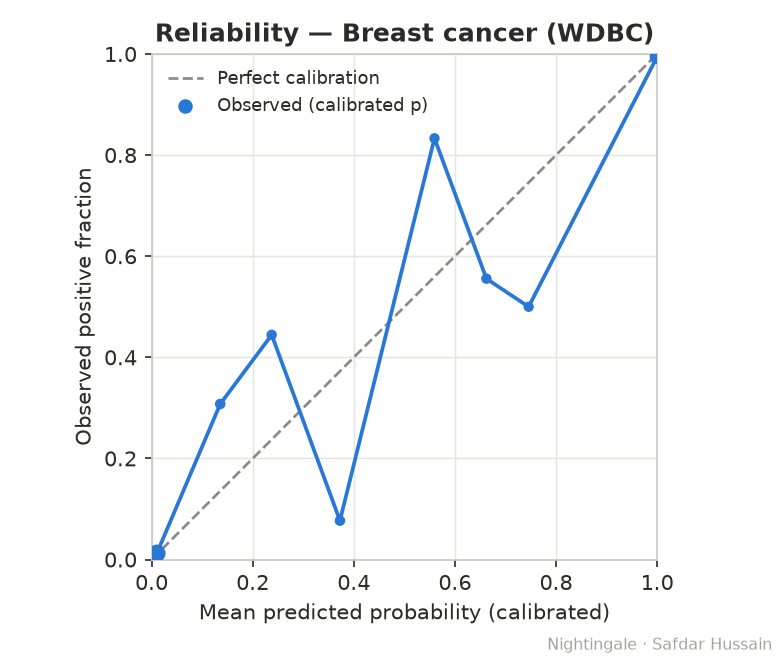

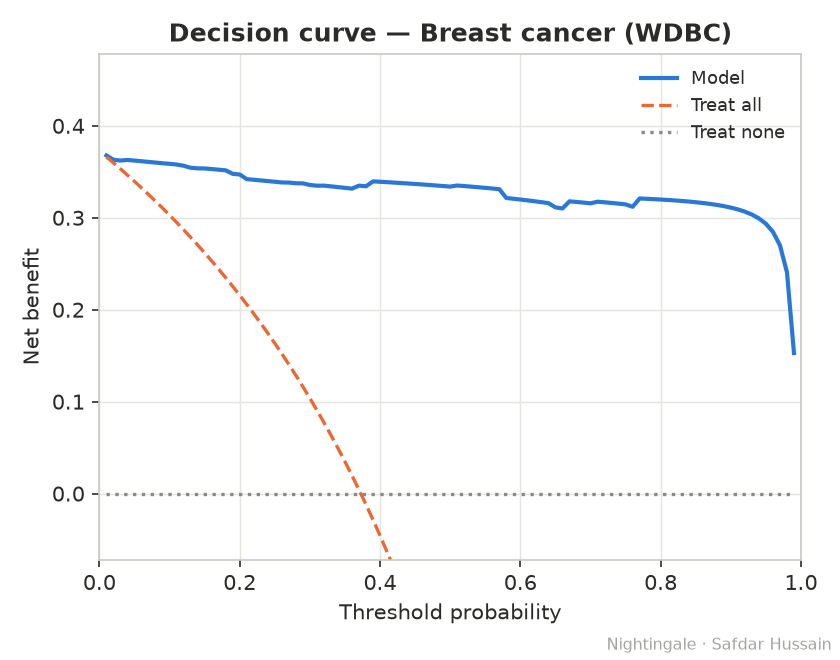

Cervical cancer (risk factors)


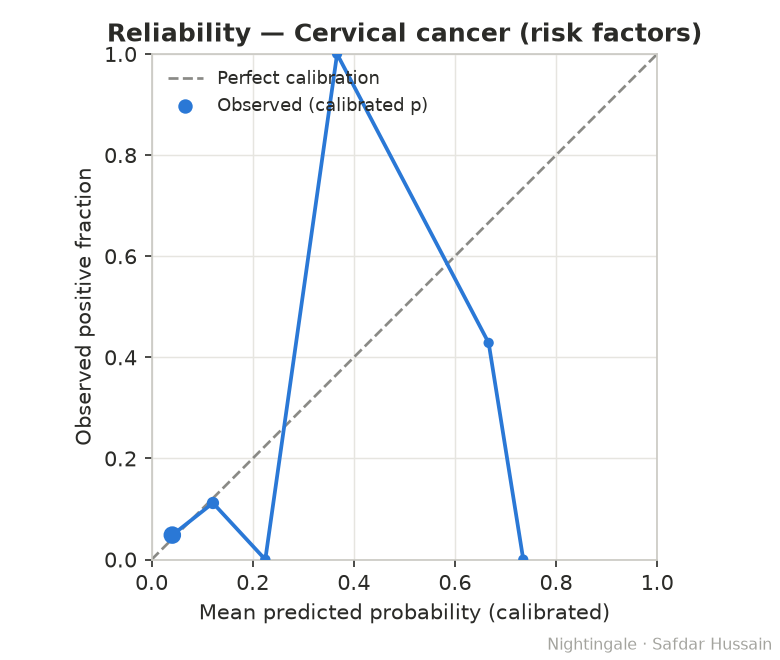

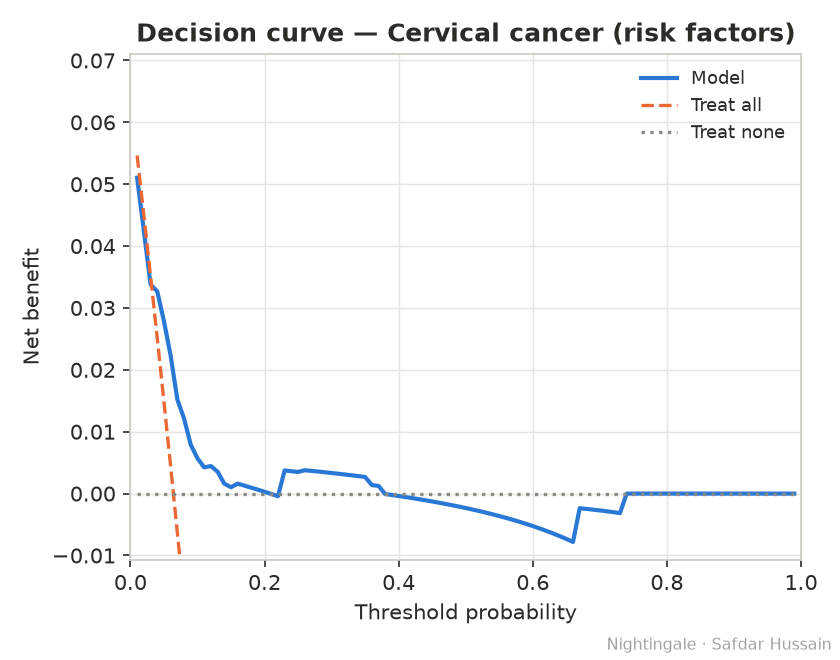

In [12]:
for slug in ["breast-cancer", "cervical-cancer"]:
    print(CONDITIONS[slug].display)
    display(Image(filename=str(FIGURES_ROOT / f"{slug}-reliability.png")))
    display(Image(filename=str(FIGURES_ROOT / f"{slug}-decision-curve.png")))

Breast-cancer's reliability curve stays close to the diagonal at the low and high ends of
the probability range, where most of its 569 rows sit, with some bin-to-bin noise in the
middle where far fewer rows land — and its decision curve clears "treat all" across almost
the whole threshold range, a genuinely strong, well-calibrated model. Cervical-cancer's
reliability curve is far noisier throughout (55 positives spread thinly across ten bins over
the whole OOF frame, so several bins hold only a handful of points), and its decision curve
only separates from "treat none" at low thresholds, consistent with the modest ROC-AUC (0.67)
and wide PR-AUC confidence interval reported above — a low-prevalence, hard condition,
published honestly rather than dressed up.

## The kidney-disease 0.998 audit

Kidney-disease's OOF ROC-AUC is loaded above — near-perfect. This project's own stated
thesis is that a too-good number is a bug report, not a result to celebrate, so it gets
investigated rather than published as-is. Two questions: is any feature a
near-deterministic function of the target, and is anything missing-by-class in a way
that would let the model read the label off which lab tests happen to be present?

The cell below computes univariate ROC-AUC for the CKD dataset's best-known biomarkers,
live, on complete cases only (no imputation, no pipeline involved) — reproducing the
audit finding directly from the cleaned data rather than quoting it.

In [13]:
from sklearn.metrics import roc_auc_score as _roc_auc_score

kidney = pd.read_csv(CLEANED_ROOT / "kidney-disease.csv.gz", compression="gzip")

biomarkers = ["hemo", "pcv", "sc", "rbcc", "sg", "al", "sod"]
biomarker_names = {
    "hemo": "hemoglobin", "pcv": "packed cell volume", "sc": "serum creatinine",
    "rbcc": "RBC count", "sg": "specific gravity", "al": "albumin", "sod": "sodium",
}

univariate_rows = []
for col in biomarkers:
    complete = kidney[[col, "target"]].dropna()
    auc = _roc_auc_score(complete["target"], complete[col])
    # direction-agnostic: report whichever side of 0.5 is farther, since some of
    # these biomarkers correlate positively and some negatively with CKD.
    auc_direction_agnostic = max(auc, 1.0 - auc)
    univariate_rows.append(
        {
            "biomarker": biomarker_names[col],
            "column": col,
            "n_complete": len(complete),
            "univariate_auc": round(auc_direction_agnostic, 3),
        }
    )

univariate_df = pd.DataFrame(univariate_rows).sort_values("univariate_auc", ascending=False)
univariate_df

,biomarker,column,n_complete,univariate_auc
0,hemoglobin,hemo,348,0.969
1,packed cell volume,pcv,329,0.952
3,RBC count,rbcc,269,0.924
2,serum creatinine,sc,383,0.923
4,specific gravity,sg,353,0.921
5,albumin,al,354,0.871
6,sodium,sod,313,0.804


In [14]:
categorical_findings = {
    "rbc": "abnormal", "pc": "abnormal", "pcc": "present", "ba": "present",
    "htn": "yes", "dm": "yes", "cad": "yes", "pe": "yes", "ane": "yes", "appet": "poor",
}

any_abnormal = pd.Series(False, index=kidney.index)
for col, positive_value in categorical_findings.items():
    any_abnormal = any_abnormal | (kidney[col] == positive_value)

trivial_pred = any_abnormal.astype(int)
trivial_accuracy = (trivial_pred == kidney["target"]).mean()
false_positives = int(((trivial_pred == 1) & (kidney["target"] == 0)).sum())
false_negatives = int(((trivial_pred == 0) & (kidney["target"] == 1)).sum())

print("Trivial rule: 'predict CKD iff ANY of these ten categorical findings is abnormal'")
print(f"  accuracy:        {trivial_accuracy:.1%}")
print(f"  false positives: {false_positives} (of {int((kidney['target'] == 0).sum())} healthy rows)")
print(f"  false negatives: {false_negatives} (of {int((kidney['target'] == 1).sum())} CKD rows)")

Trivial rule: 'predict CKD iff ANY of these ten categorical findings is abnormal'
  accuracy:        93.0%
  false positives: 0 (of 150 healthy rows)
  false negatives: 28 (of 250 CKD rows)


Several individual biomarkers clear 0.90+ univariate ROC-AUC on their own, and every one
of them is a textbook CKD signal — anemia (hemoglobin/packed-cell-volume/RBC count, all
driven down by reduced erythropoietin), reduced glomerular filtration (serum
creatinine), and proteinuria (specific gravity, albumin). Combined with a trivial
categorical-findings rule that scores well above chance with zero false positives on the
healthy group, the picture is consistent: **this specific 400-row published benchmark is
close to linearly separable**, because it was assembled as two clearly distinguishable
groups (a confirmed CKD caseload vs. a comparison set of people with unremarkable labs),
not sampled from one continuous, diagnostically ambiguous population. Nothing here is a
disguised copy of the target column — no single feature or transform reproduces it with
100% fidelity — but the 0.998 should be read as "this academic benchmark is nearly
separable," not as "a deployed screening model would score 99.8% AUC on real,
undifferentiated primary-care patients."

## Conformal coverage

`nightingale.conformal.conformal_qhat` computes a single threshold from a calibration
sample such that the prediction set built by `prediction_set` contains the true label
with probability at least `1 - alpha` for a fresh exchangeable point. This project uses
the pooled out-of-fold frame as that calibration sample ("cross-conformal over OOF") —
legitimate because every `p_cal` value already comes from a calibrator that never saw
its own row.

The cell below reproduces `q_hat` and the verdict distribution for two conditions,
live, from each condition's committed OOF file, and confirms the result matches the
published `metrics.json` exactly.

In [15]:
def conformal_summary(slug, alpha=0.1):
    oof = pd.read_csv(MODELS_ROOT / slug / "oof_predictions.csv.gz", compression="gzip")
    y = oof["y_true"].to_numpy()
    p = oof["p_cal"].to_numpy()

    q_hat = conformal_qhat(y, p, alpha=alpha)
    verdicts = [prediction_set(float(pi), q_hat) for pi in p]
    n = len(verdicts)
    uncertain_frac = verdicts.count("uncertain") / n

    with open(MODELS_ROOT / slug / "metrics.json") as f:
        committed = json.load(f)
    committed_q_hat = committed["conformal"]["q_hat"]
    committed_uncertain = committed["conformal"]["verdict_fractions"]["uncertain"]

    return {
        "condition": CONDITIONS[slug].display,
        "n": n,
        "q_hat (live)": q_hat,
        "q_hat (committed)": committed_q_hat,
        "uncertain_rate (live)": uncertain_frac,
        "uncertain_rate (committed)": committed_uncertain,
    }

conformal_rows = [conformal_summary(slug) for slug in ["breast-cancer", "cervical-cancer"]]
conformal_df = pd.DataFrame(conformal_rows).set_index("condition")
conformal_df

,n,q_hat (live),q_hat (committed),uncertain_rate (live),uncertain_rate (committed)
condition,,,,,
Breast cancer (WDBC),569,0.111111,0.111111,0.0,0.0
Cervical cancer (risk factors),858,0.155172,0.155172,0.0,0.0


Breast-cancer's `q_hat` sits well under 0.5 — the model is confident and well-separated
enough that no probability value can ever land in the "uncertain" band, so the uncertain
rate is structurally 0%. Cervical-cancer's `q_hat` is higher (a harder, noisier 6.4%-prevalence
condition), giving a non-trivial uncertain rate: the conformal layer surfaces exactly the
cases the underlying model is least confident about, rather than forcing every row into a
binary call.

## Limitations, stated plainly

- **Small cohorts.** Cervical-cancer (858 rows, 55 positives), kidney-disease (400 rows),
  and liver-disease (583 rows) are all small enough that per-condition confidence
  intervals are genuinely wide — the point estimates above should not be read with more
  precision than their intervals support.
- **Self-reported labels.** Diabetes's target (`Diabetes_binary`) comes from the CDC's
  BRFSS 2015 telephone survey — a self-reported diagnosis, not a clinical one. The model
  learns to predict what respondents told a surveyor, not a lab-confirmed diagnosis.
- **55 positives is not a lot of signal.** Cervical-cancer's PR-AUC confidence interval
  (loaded above) is wide enough that its upper bound is more than twice its lower bound —
  published as measured, not smoothed into a tighter-sounding number.
- **Kidney-disease's near-perfect AUC is a property of this specific published academic
  benchmark**, not a claim about how a deployed screening model would perform on an
  undifferentiated population — see the audit above.
- **None of these six models has been validated on a population outside its own UCI
  source.** The one condition this project does check across independent sites —
  heart-disease, across four hospitals — is the subject of the companion notebook,
  `02_external_validation.ipynb`, and the honest result there is not uniformly good
  news.